In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

print("✅ Libraries imported!")

✅ Libraries imported!


In [4]:
df = pd.read_csv("housing.csv")
print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Stats ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None

=== Missing Values ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income      

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


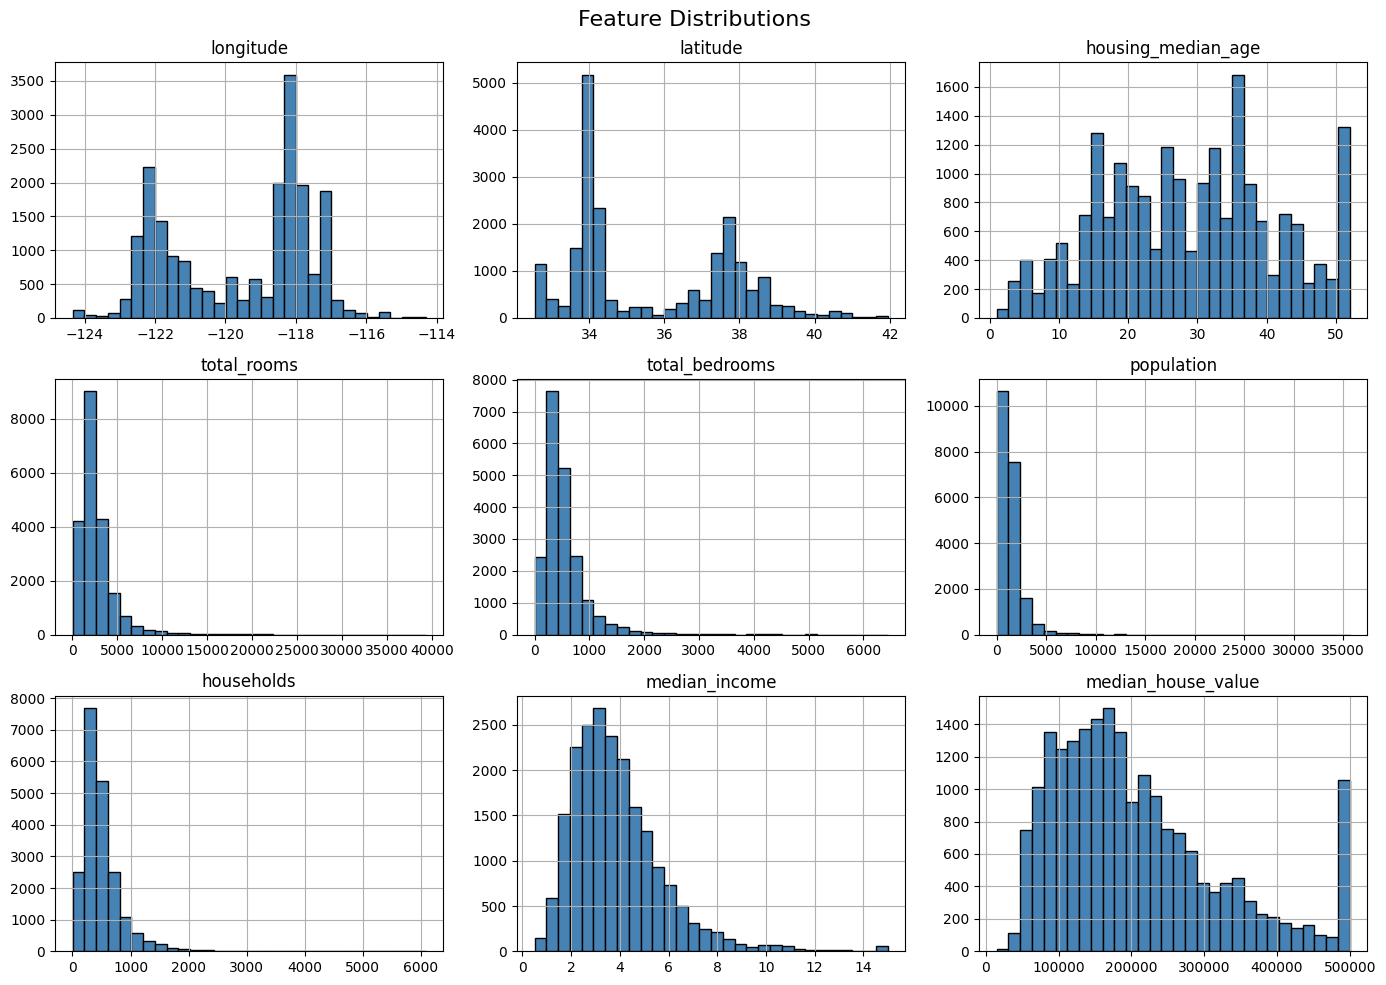

In [8]:
df.hist(bins=30, figsize=(14, 10), color='steelblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
# Missing values fill karo
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

# Categorical encode karo
le = LabelEncoder()
df["ocean_proximity"] = le.fit_transform(df["ocean_proximity"])

print("✅ Preprocessing done!")
print("Missing values:", df.isnull().sum().sum())

✅ Preprocessing done!
Missing values: 0


In [10]:
df["rooms_per_household"]      = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]        = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]     / df["households"]

print("✅ New features added!")
print("New shape:", df.shape)
df.head()

✅ New features added!
New shape: (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,3,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,6.281853,0.172096,2.181467


In [11]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split done!")
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

✅ Data split done!
Train size: (16512, 12)
Test size : (4128, 12)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling done!")

✅ Scaling done!


In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=20, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

kf      = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring="r2")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae     = mean_absolute_error(y_test, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
    r2      = r2_score(y_test, y_pred)
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()

    results.append({
        "Model":   name,
        "MAE":     round(mae, 2),
        "RMSE":    round(rmse, 2),
        "R2":      round(r2, 4),
        "CV R2":   round(cv_mean, 4),
        "CV Std":  round(cv_std, 4),
    })

    print(f"📌 {name}")
    print(f"   MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R²: {r2:.4f} | CV R²: {cv_mean:.4f} ± {cv_std:.4f}\n")
    

📌 Linear Regression
   MAE: 51,942 | RMSE: 74,267 | R²: 0.5791 | CV R²: 0.6479 ± 0.0145

📌 Random Forest
   MAE: 34,635 | RMSE: 53,296 | R²: 0.7832 | CV R²: 0.7880 ± 0.0065

📌 Gradient Boosting
   MAE: 50,387 | RMSE: 68,457 | R²: 0.6424 | CV R²: 0.6575 ± 0.0115

📌 XGBoost
   MAE: 31,554 | RMSE: 48,135 | R²: 0.8232 | CV R²: 0.8299 ± 0.0026



In [14]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df.index = range(1, len(results_df)+1)
print("="*65)
print("                    FINAL RESULTS")
print("="*65)
print(results_df.to_string())

                    FINAL RESULTS
               Model       MAE      RMSE      R2   CV R2  CV Std
1            XGBoost  31554.13  48134.97  0.8232  0.8299  0.0026
2      Random Forest  34634.80  53296.18  0.7832  0.7880  0.0065
3  Gradient Boosting  50386.73  68457.08  0.6424  0.6575  0.0115
4  Linear Regression  51941.97  74267.08  0.5791  0.6479  0.0145


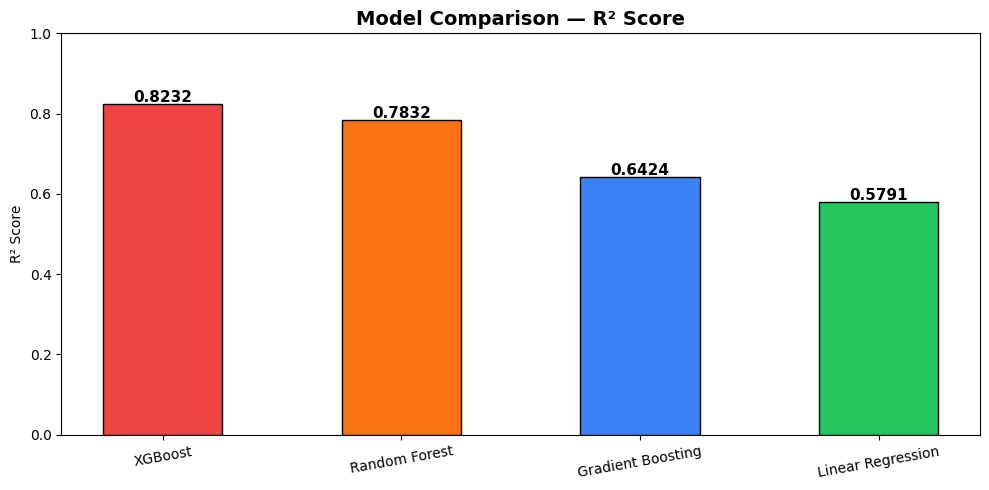

In [15]:
plt.figure(figsize=(10, 5))
colors = ['#ef4444', '#f97316', '#3b82f6', '#22c55e']
bars = plt.bar(results_df["Model"], results_df["R2"], color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, results_df["R2"]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.4f}", ha='center', fontsize=11, fontweight='bold')

plt.title("Model Comparison — R² Score", fontsize=14, fontweight='bold')
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [16]:
best_row   = results_df.iloc[0]
best_name  = best_row["Model"]
best_model = models[best_name]

joblib.dump(best_model,      "model.pkl")
joblib.dump(scaler,          "scaler.pkl")
joblib.dump(list(X.columns), "features.pkl")

print("="*45)
print(f"  🏆 Best Model  : {best_name}")
print(f"  🎯 R² Score    : {best_row['R2']}")
print(f"  📈 Accuracy    : {best_row['R2']*100:.2f}%")
print(f"  📉 MAE         : {best_row['MAE']:,}")
print(f"  📉 RMSE        : {best_row['RMSE']:,}")
print("="*45)
print("✅ model.pkl saved!")
print("✅ scaler.pkl saved!")
print("✅ features.pkl saved!")

  🏆 Best Model  : XGBoost
  🎯 R² Score    : 0.8232
  📈 Accuracy    : 82.32%
  📉 MAE         : 31,554.13
  📉 RMSE        : 48,134.97
✅ model.pkl saved!
✅ scaler.pkl saved!
✅ features.pkl saved!
